# ERA5 India 2025 — Descriptive Analysis
Wind (`wcf`) and solar (`scf`) capacity factors computed from hourly ERA5 reanalysis.

In [15]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings('ignore')

wcf = xr.open_dataset('../data/proc/era5/wcf_era5_india_2025_hourly.nc')['wcf']
scf = xr.open_dataset('../data/proc/era5/scf_era5_india_2025_hourly.nc')['scf'].clip(min=0)

print('wcf:', wcf.dims, wcf.shape)
print('scf:', scf.dims, scf.shape)

wcf: ('time', 'lat', 'lon') (8760, 125, 117)
scf: ('time', 'lat', 'lon') (8760, 125, 117)


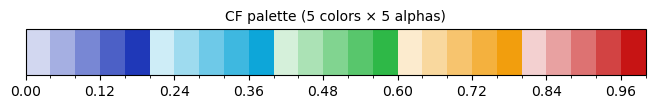

In [16]:
import matplotlib.colors as mcolors

# Custom colormap: 5 hues × 5 alpha levels = 25 discrete steps
# Hues match the reference palette: blue → cyan → green → orange → red
_base_colors = [
    (0.12, 0.22, 0.72),   # blue
    (0.05, 0.65, 0.85),   # cyan
    (0.18, 0.72, 0.28),   # green
    (0.95, 0.62, 0.05),   # orange
    (0.78, 0.08, 0.08),   # red
]
_alphas = [0.2, 0.4, 0.6, 0.8, 1.0]

_rgba = [(*rgb, a) for rgb in _base_colors for a in _alphas]
CF_CMAP = mcolors.ListedColormap(_rgba, name='cf_palette')
CF_CMAP.set_bad(color='lightgrey')   # NaN -> grey

# Colorbar boundaries for 25 bins
def cf_norm(vmin, vmax):
    return mcolors.BoundaryNorm(np.linspace(vmin, vmax, 26), CF_CMAP.N)

# Quick preview
fig, ax = plt.subplots(figsize=(8, 0.6))
cb = plt.colorbar(plt.cm.ScalarMappable(cmap=CF_CMAP, norm=cf_norm(0, 1)),
                  cax=ax, orientation='horizontal')
ax.set_title('CF palette (5 colors × 5 alphas)', fontsize=10)
plt.tight_layout()
plt.show()

In [17]:
scf

<xarray.DataArray 'scf' (time: 8760, lat: 125, lon: 117)> Size: 512MB
array([[[0.        , 0.        , 0.        , ..., 0.00175799,
         0.00218539, 0.00264663],
        [0.        , 0.        , 0.        , ..., 0.00166003,
         0.00205303, 0.0024644 ],
        [0.        , 0.        , 0.        , ..., 0.00155689,
         0.0018978 , 0.0022589 ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.08183017,
         0.08888765, 0.09538671],
        [0.        , 0.        , 0.        , ..., 0.08444922,
         0.09097079, 0.09724754],
        [0.        , 0.        , 0.        , ..., 0.08807005,
         0.09344951, 0.09895498],
...
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2025-01-01 ... 2025-12-31T23:00:00
  * lat      (lat) float64 1kB 6.0 6.25 6.5 6.75 7.0 ... 36.25 36.5 36.75 37.0
  * lon      (lon) float64 936B 68.0 68.25 68.5 68.75 ... 96.25 96.5 96.75 97.0

## 1. Annual mean capacity factors

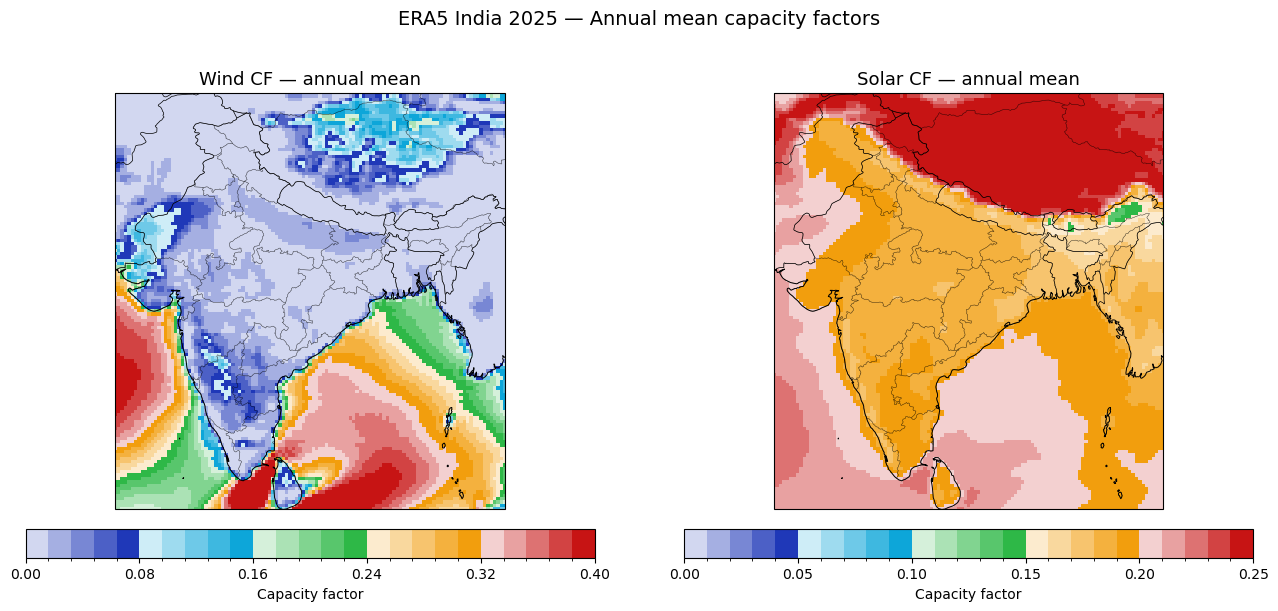

In [18]:
wcf_mean = wcf.mean('time').compute()
scf_mean = scf.mean('time', skipna=True).compute()

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          subplot_kw={'projection': ccrs.PlateCarree()})

for ax, da, title, vmin, vmax in [
    (axes[0], wcf_mean, 'Wind CF — annual mean',  0.0, 0.40),
    (axes[1], scf_mean, 'Solar CF — annual mean', 0.0, 0.25),
]:
    norm = cf_norm(vmin, vmax)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5)
    im = ax.pcolormesh(da.lon, da.lat, da.values,
                       cmap=CF_CMAP, norm=norm, transform=ccrs.PlateCarree())
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, shrink=0.8,
                 label='Capacity factor', ticks=np.linspace(vmin, vmax, 6))
    ax.set_title(title, fontsize=13)
    ax.set_extent([68, 97, 6, 37], crs=ccrs.PlateCarree())

plt.suptitle('ERA5 India 2025 — Annual mean capacity factors', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/proc/era5/fig_annual_mean_cf.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Seasonal means

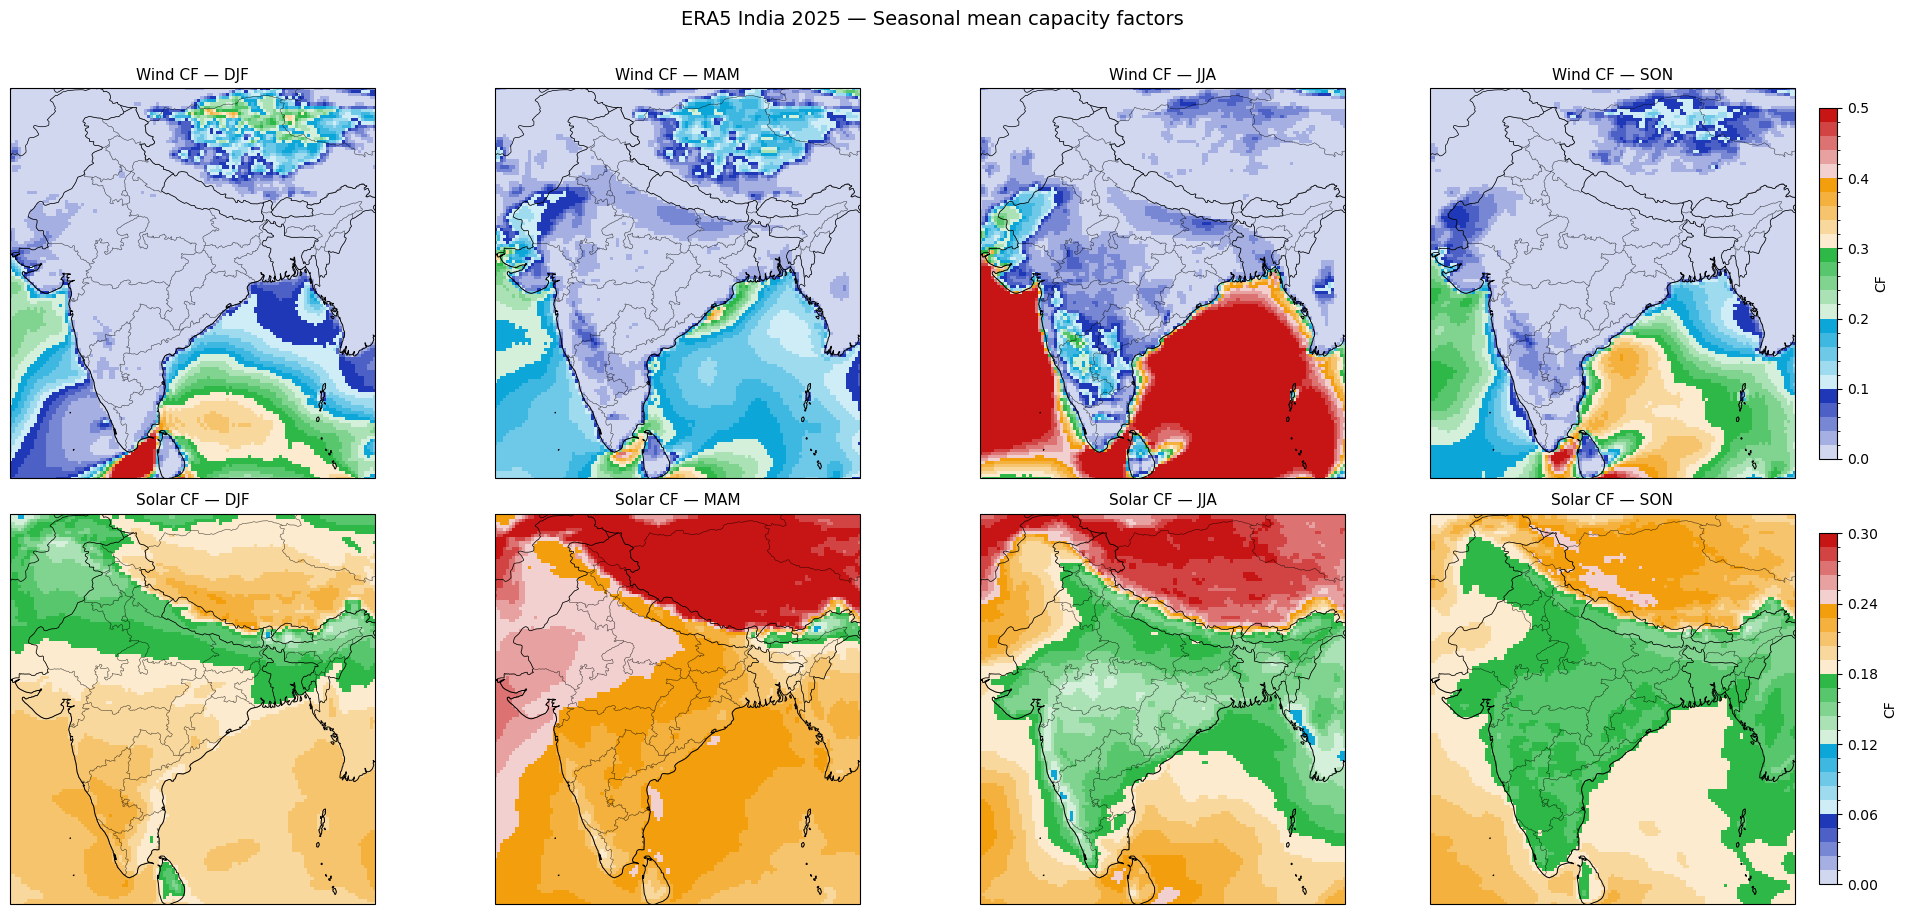

In [19]:
season_months = {'DJF': [12,1,2], 'MAM': [3,4,5], 'JJA': [6,7,8], 'SON': [9,10,11]}

vmaxes = {'Wind CF': 0.50, 'Solar CF': 0.30}

fig, axes = plt.subplots(2, 4, figsize=(20, 9),
                          subplot_kw={'projection': ccrs.PlateCarree()})

for row, (da, label, vmax) in enumerate([
    (wcf, 'Wind CF',  0.50),
    (scf, 'Solar CF', 0.30),
]):
    norm = cf_norm(0, vmax)
    for col, (season, months) in enumerate(season_months.items()):
        da_s = da.sel(time=da.time.dt.month.isin(months)).mean('time').compute()
        ax = axes[row, col]
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
        ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5)
        im = ax.pcolormesh(da_s.lon, da_s.lat, da_s.values,
                           cmap=CF_CMAP, norm=norm, transform=ccrs.PlateCarree())
        ax.set_title(f'{label} — {season}', fontsize=11)
        ax.set_extent([68, 97, 6, 37], crs=ccrs.PlateCarree())
        if col == 3:
            plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.9,
                         label='CF', ticks=np.linspace(0, vmax, 6))

plt.suptitle('ERA5 India 2025 — Seasonal mean capacity factors', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/proc/era5/fig_seasonal_cf.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Monthly mean time series (India-wide spatial average)

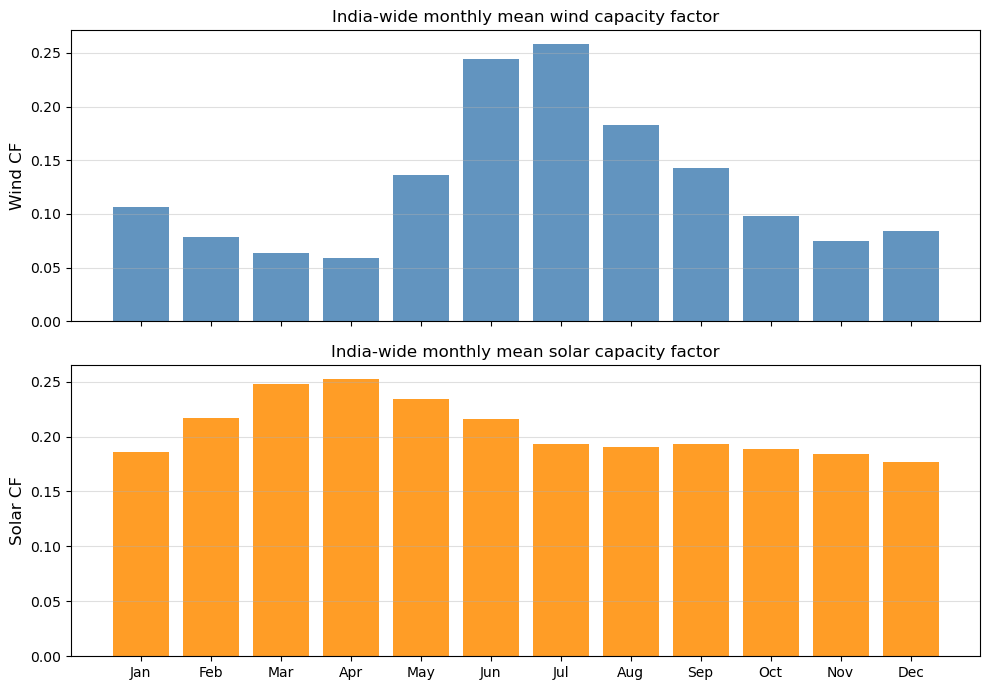

In [20]:
wcf_monthly = wcf.mean(['lat', 'lon']).resample(time='ME').mean().compute()
scf_monthly = scf.mean(['lat', 'lon']).resample(time='ME').mean().compute()

month_labels = pd.date_range('2025-01', periods=12, freq='ME').strftime('%b')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.bar(range(12), wcf_monthly.values, color='steelblue', alpha=0.85)
ax1.set_ylabel('Wind CF', fontsize=12)
ax1.set_title('India-wide monthly mean wind capacity factor', fontsize=12)
ax1.set_ylim(0)
ax1.grid(axis='y', alpha=0.4)

ax2.bar(range(12), scf_monthly.values, color='darkorange', alpha=0.85)
ax2.set_ylabel('Solar CF', fontsize=12)
ax2.set_title('India-wide monthly mean solar capacity factor', fontsize=12)
ax2.set_xticks(range(12))
ax2.set_xticklabels(month_labels)
ax2.set_ylim(0)
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('../data/proc/era5/fig_monthly_ts.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Diurnal cycle

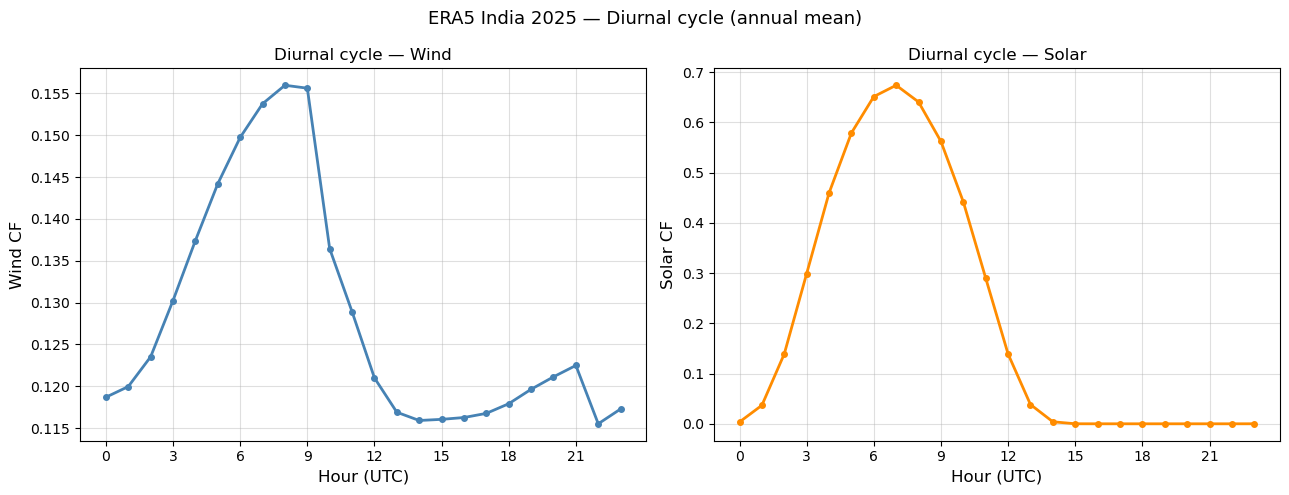

In [21]:
wcf_diurnal = wcf.mean(['lat', 'lon']).groupby('time.hour').mean().compute()
scf_diurnal = scf.mean(['lat', 'lon']).groupby('time.hour').mean().compute()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(wcf_diurnal.hour, wcf_diurnal.values, color='steelblue', lw=2, marker='o', ms=4)
ax1.set_xlabel('Hour (UTC)', fontsize=12)
ax1.set_ylabel('Wind CF', fontsize=12)
ax1.set_title('Diurnal cycle — Wind', fontsize=12)
ax1.set_xticks(range(0, 24, 3))
ax1.grid(alpha=0.4)

ax2.plot(scf_diurnal.hour, scf_diurnal.values, color='darkorange', lw=2, marker='o', ms=4)
ax2.set_xlabel('Hour (UTC)', fontsize=12)
ax2.set_ylabel('Solar CF', fontsize=12)
ax2.set_title('Diurnal cycle — Solar', fontsize=12)
ax2.set_xticks(range(0, 24, 3))
ax2.grid(alpha=0.4)

plt.suptitle('ERA5 India 2025 — Diurnal cycle (annual mean)', fontsize=13)
plt.tight_layout()
plt.savefig('../data/proc/era5/fig_diurnal_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Distribution of hourly capacity factors

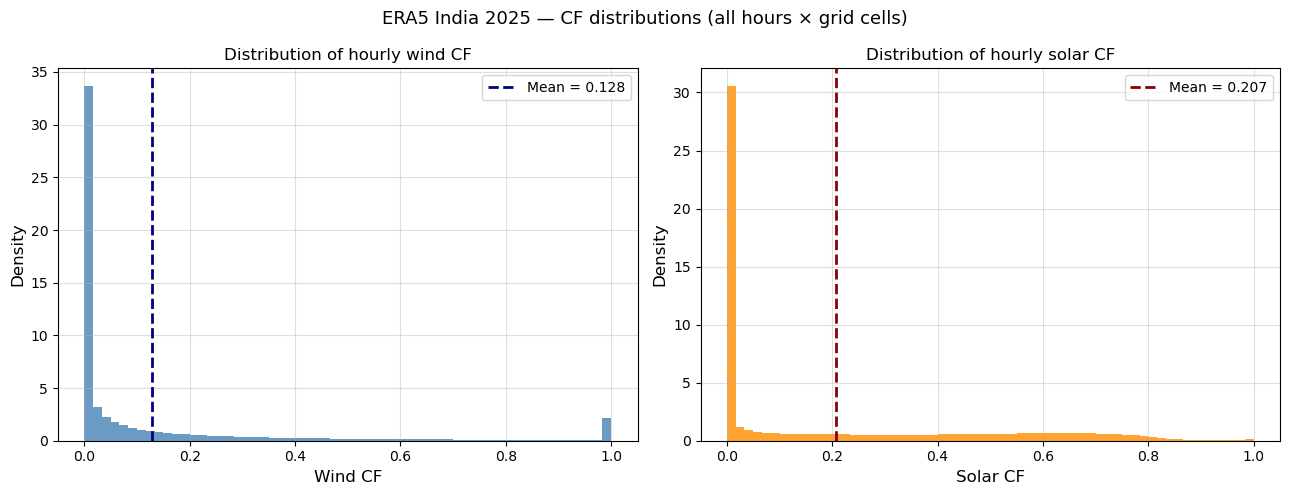

In [22]:
wcf_flat = wcf.values.flatten()
scf_flat = scf.values.flatten()
wcf_flat = wcf_flat[~np.isnan(wcf_flat)]
scf_flat = scf_flat[~np.isnan(scf_flat)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.hist(wcf_flat, bins=60, color='steelblue', alpha=0.8, density=True)
ax1.axvline(wcf_flat.mean(), color='navy', lw=2, ls='--',
            label=f'Mean = {wcf_flat.mean():.3f}')
ax1.set_xlabel('Wind CF', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Distribution of hourly wind CF', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.4)

ax2.hist(scf_flat, bins=60, color='darkorange', alpha=0.8, density=True)
ax2.axvline(scf_flat.mean(), color='darkred', lw=2, ls='--',
            label=f'Mean = {scf_flat.mean():.3f}')
ax2.set_xlabel('Solar CF', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Distribution of hourly solar CF', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.4)

plt.suptitle('ERA5 India 2025 — CF distributions (all hours × grid cells)', fontsize=13)
plt.tight_layout()
plt.savefig('../data/proc/era5/fig_cf_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Monsoon vs non-monsoon comparison

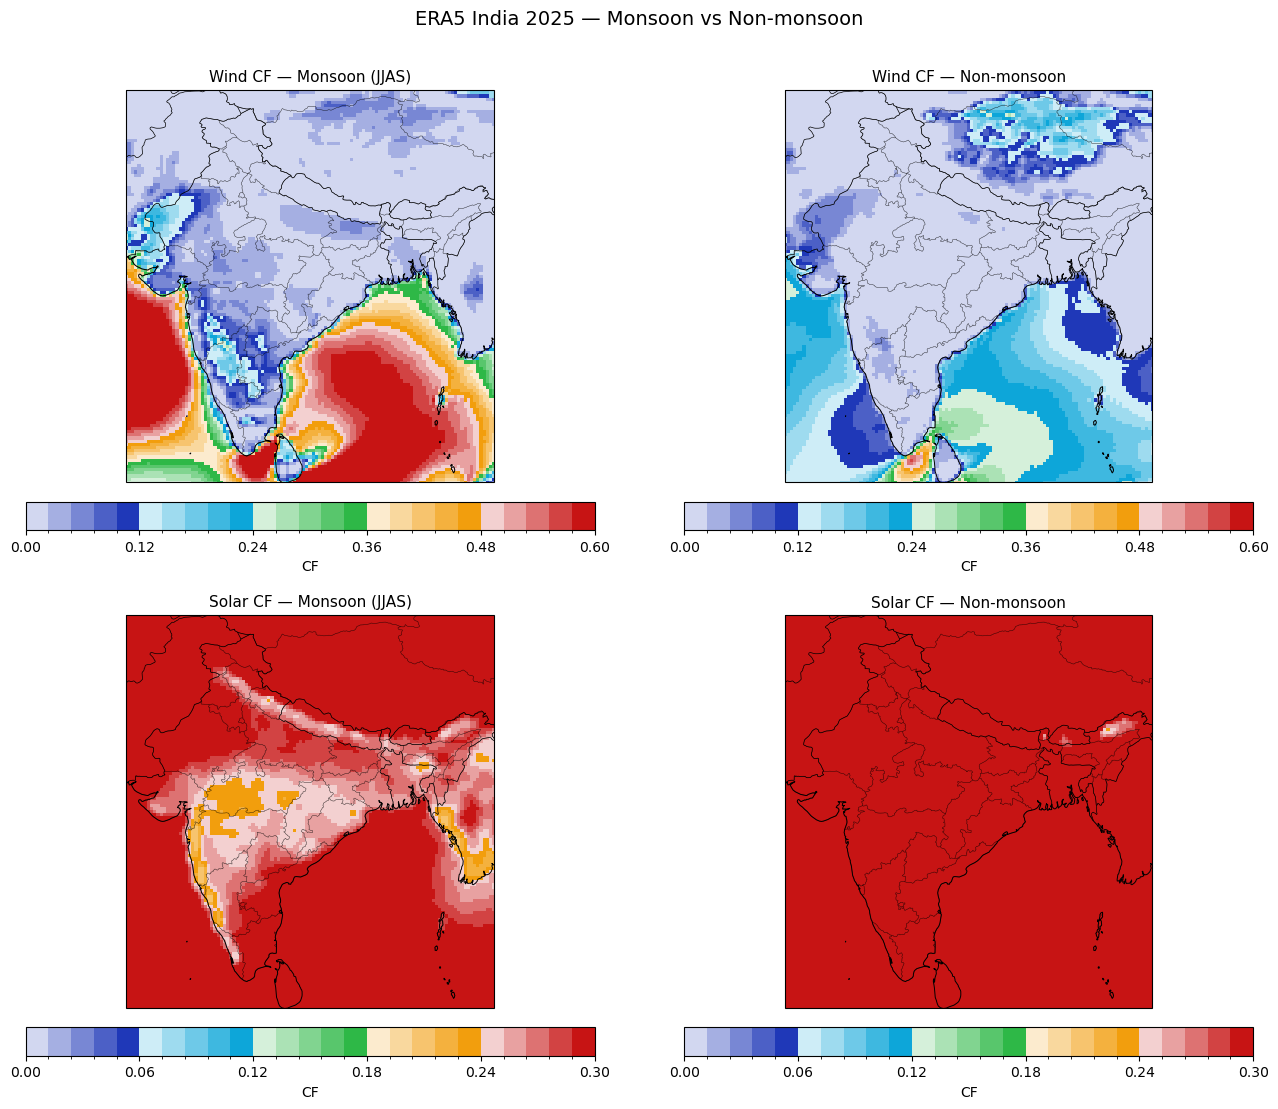

In [23]:
monsoon     = [6, 7, 8, 9]
non_monsoon = [1, 2, 3, 4, 5, 10, 11, 12]

panels = [
    (wcf.sel(time=wcf.time.dt.month.isin(monsoon)).mean('time').compute(),
     'Wind CF — Monsoon (JJAS)',  0, 0.6),
    (wcf.sel(time=wcf.time.dt.month.isin(non_monsoon)).mean('time').compute(),
     'Wind CF — Non-monsoon',     0, 0.6),
    (scf.sel(time=scf.time.dt.month.isin(monsoon)).where(
        scf.sel(time=scf.time.dt.month.isin(monsoon)) > 0).mean('time', skipna=True).compute(),
     'Solar CF — Monsoon (JJAS)', 0, 0.30),
    (scf.sel(time=scf.time.dt.month.isin(non_monsoon)).where(
        scf.sel(time=scf.time.dt.month.isin(non_monsoon)) > 0).mean('time', skipna=True).compute(),
     'Solar CF — Non-monsoon',    0, 0.30),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11),
                          subplot_kw={'projection': ccrs.PlateCarree()})

for ax, (da, title, vmin, vmax) in zip(axes.flat, panels):
    norm = cf_norm(vmin, vmax)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5)
    im = ax.pcolormesh(da.lon, da.lat, da.values,
                       cmap=CF_CMAP, norm=norm, transform=ccrs.PlateCarree())
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, shrink=0.8,
                 label='CF', ticks=np.linspace(vmin, vmax, 6))
    ax.set_title(title, fontsize=11)
    ax.set_extent([68, 97, 6, 37], crs=ccrs.PlateCarree())

plt.suptitle('ERA5 India 2025 — Monsoon vs Non-monsoon', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/proc/era5/fig_monsoon_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary statistics

In [ ]:
stats = pd.DataFrame({
    'Wind CF': {
        'Mean':   float(wcf.mean()),
        'Median': float(wcf.median()),
        'Std':    float(wcf.std()),
        'P10':    float(wcf.quantile(0.10)),
        'P90':    float(wcf.quantile(0.90)),
        'Max':    float(wcf.max()),
    },
    'Solar CF': {
        'Mean':   float(scf.mean()),
        'Median': float(scf.median()),
        'Std':    float(scf.std()),
        'P10':    float(scf.quantile(0.10)),
        'P90':    float(scf.quantile(0.90)),
        'Max':    float(scf.max()),
    },
})
stats.round(4)

,Wind CF,Solar CF
Mean,0.1280,0.2065
Median,0.0041,0.0106
Std,0.2302,0.2544
P10,0.0000,0.0000
P90,0.4578,0.6660
Max,1.0000,1.0000


: 